**Optimization**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fbourgey/fre-gy-7773-mlfe/blob/main/06_optimization_linreg.ipynb)

# Imports

In [137]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import add_dummy_feature

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

## Models gradients and losses

We want to minimize a goodness-of-fit function $f$ 

$$
\arg\min_{w \in \mathbb{R}^d}
\left\{
f(w)
\right\}
$$

where $d$ is the number of features and where we assume that $f$ is $L$-smooth. 
We will consider below the following cases.

### Linear regression

$$
\begin{aligned}
f(w)
&= \frac{1}{n} \sum_{i=1}^n f_i(w) \\
&= \frac{1}{2n} \sum_{i=1}^n \bigl(y_i - x_i^\top w\bigr)^2 \\
% + \frac{\lambda}{2}\,\|w\|_2^2 
&= \frac{1}{2n} \|y - Xw\|_2^2
% + \frac{\lambda}{2}\,\|w\|_2^2 .
\end{aligned}
$$

where 
- $n$ is the sample size,  
- $y = [y_1,\dots,y_n]^\top $ is the vector of labels and  
- $X$ is the matrix of features with rows containing the feature vectors $ x_i \in \mathbb{R}^d $.

# Gradient Descent

In [138]:
rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

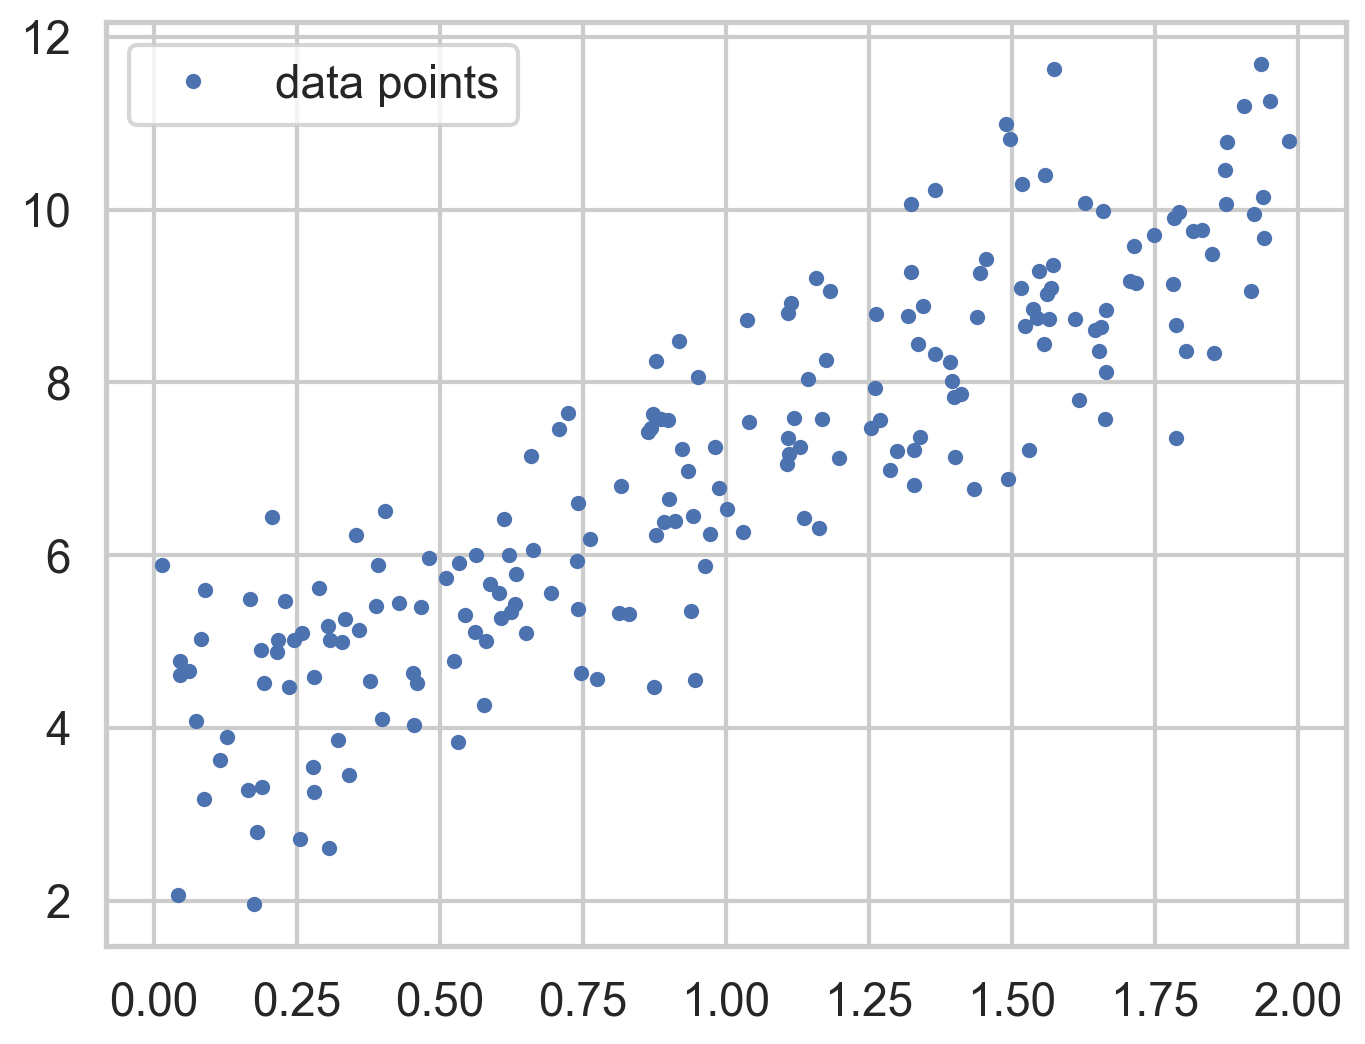

In [139]:
fig, ax = plt.subplots()
ax.plot(X, y, ".b", label="data points")
ax.legend()
plt.show()

In [ ]:
# Linear regression with an intercept term
lin_reg = # TODO

(array([3.69084138]), array([[3.32960458]]))

In [141]:
X_b = add_dummy_feature(X)
X_b.shape

(200, 2)

## Batch gradient descent

In [ ]:
eta = 1e-1  # learning rate
n_epochs = 1000
m = len(X_b)  # number of instances

rng = np.random.default_rng(seed=42)

# to store the model parameters at each epoch
theta_path_bgd = np.empty((n_epochs + 1, 2))
theta_path_bgd[0] = rng.standard_normal(2)  # randomly initialized model parameters

for n in range(n_epochs):
    theta = theta_path_bgd[n, :]
    gradients = # TODO
    theta_path_bgd[n + 1, :] = # TODO

In [143]:
theta_path_bgd

array([[ 0.30471708, -1.03998411],
       [ 1.07493087, -0.14060814],
       [ 1.67928841,  0.56641643],
       ...,
       [ 3.69084146,  3.32960452],
       [ 3.69084146,  3.32960452],
       [ 3.69084146,  3.32960452]], shape=(1001, 2))

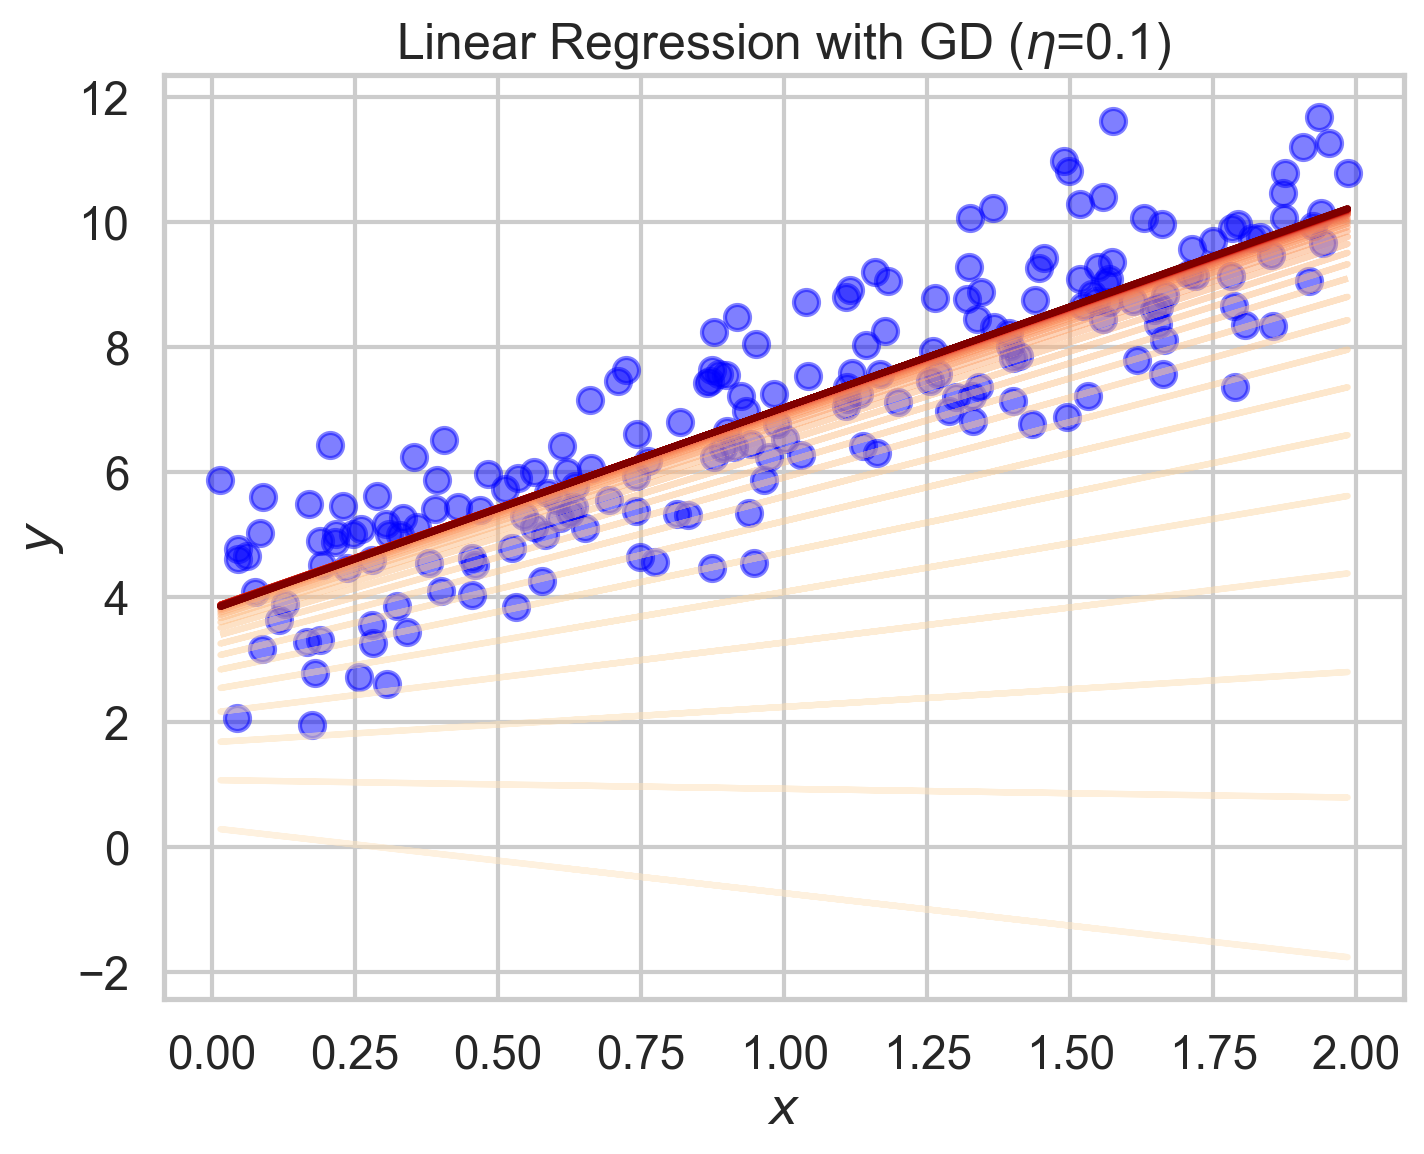

In [ ]:
n_max = 50
fig, ax = plt.subplots()
for n in range(n_max):
    y_pred = # TODO
    color = mpl.colors.rgb2hex(plt.cm.OrRd(n / n_max + 0.15))
    ax.plot(X, y_pred, color=color, alpha=0.5)
ax.scatter(X, y, color="blue", alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(rf"Linear Regression with GD ($\eta$={eta})")
plt.show()

## Stochastic gradient descent

In [ ]:
theta_path_sgd = []
n_epochs = 50

# SGD schedule
t0, t1 = 5, 50


def learning_schedule(t):
    return t0 / (t + t1)


rng = np.random.default_rng(seed=42)

theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = # TODO
        yi = # TODO
        gradients = # TODO  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)  # learning rate
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)

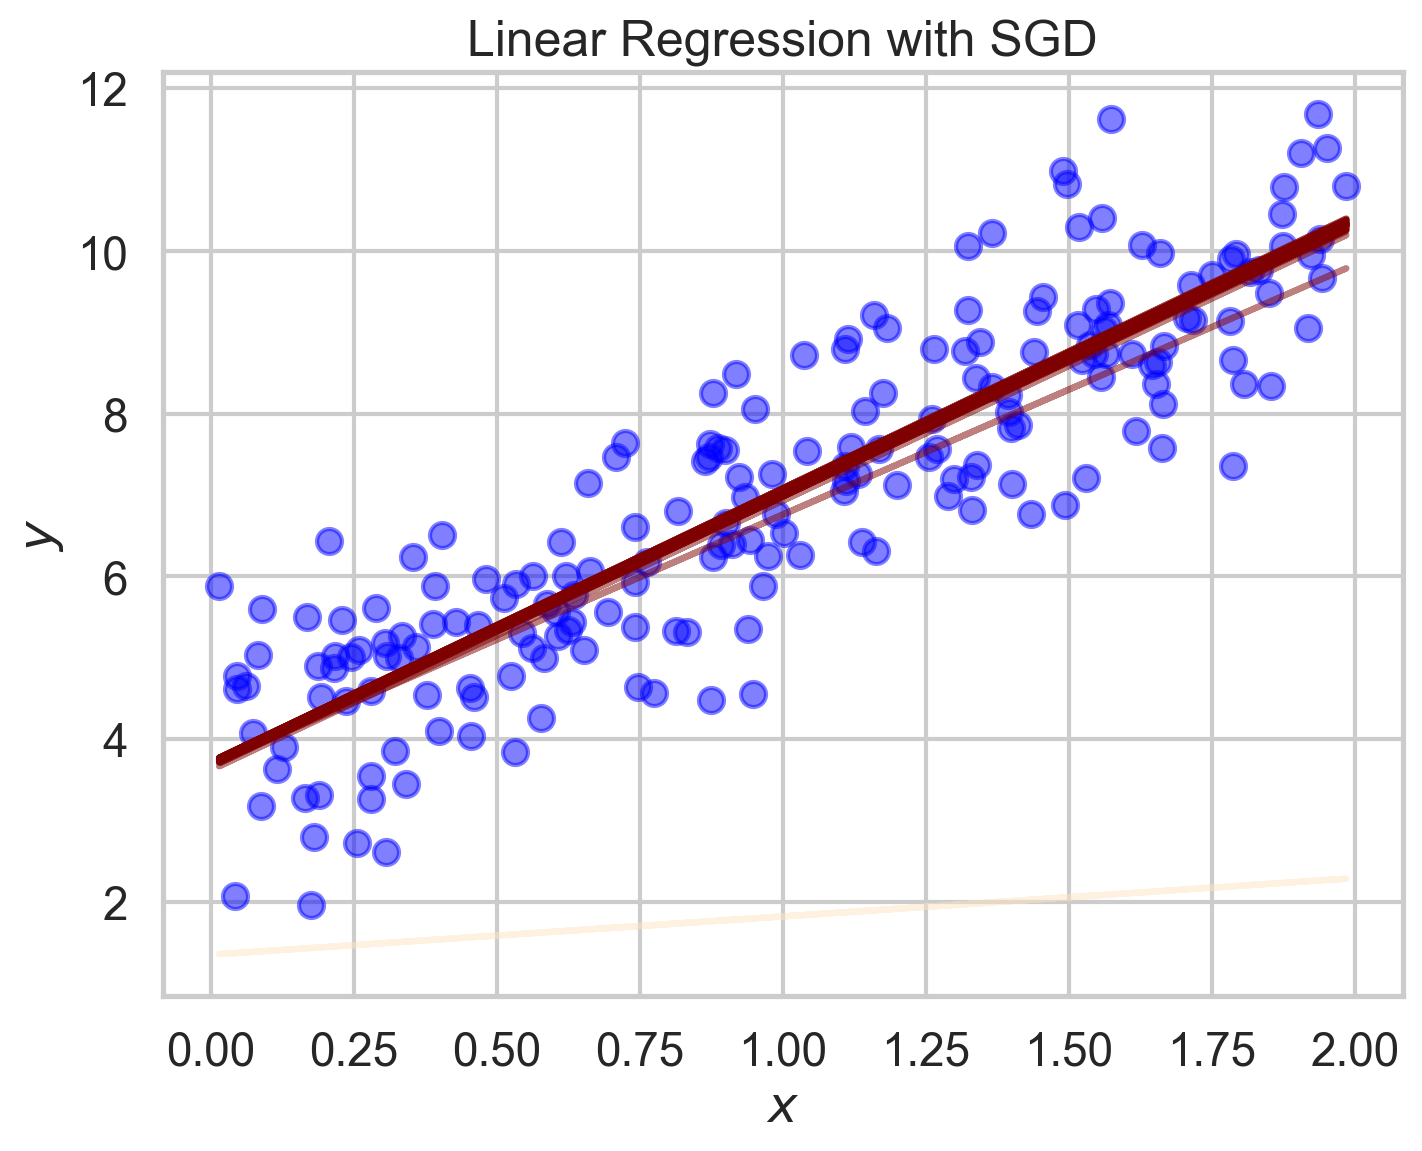

In [ ]:
n_tot = len(theta_path_sgd)
fig, ax = plt.subplots()
for n in range(len(theta_path_sgd)):
    if n % m == 0:
        theta = theta_path_sgd[n]
        y_pred = # TODO
        color = mpl.colors.rgb2hex(plt.cm.OrRd(n / n_max + 0.15))
        ax.plot(X, y_pred, color=color, alpha=0.5)
ax.scatter(X, y, color="blue", alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Linear Regression with SGD")
plt.show()

# Mini-batch gradient descent

In [ ]:
n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = m // minibatch_size

# Mini-batch schedule
t0, t1 = 200, 1000


def learning_schedule(t):
    return t0 / (t + t1)


rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters
t0, t1 = 200, 1000  # learning schedule hyperparameters

theta_path_mgd = []
for epoch in range(n_epochs):
    # each epoch, shuffle the training set
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = # TODO
    y_shuffled = # TODO
    # generate mini-batches and perform updates
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = # TODO
        yi = # TODO
        gradients = # TODO
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = # TODO
        theta_path_mgd.append(theta)

In [ ]:
# convert to numpy arrays
theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

# Plots

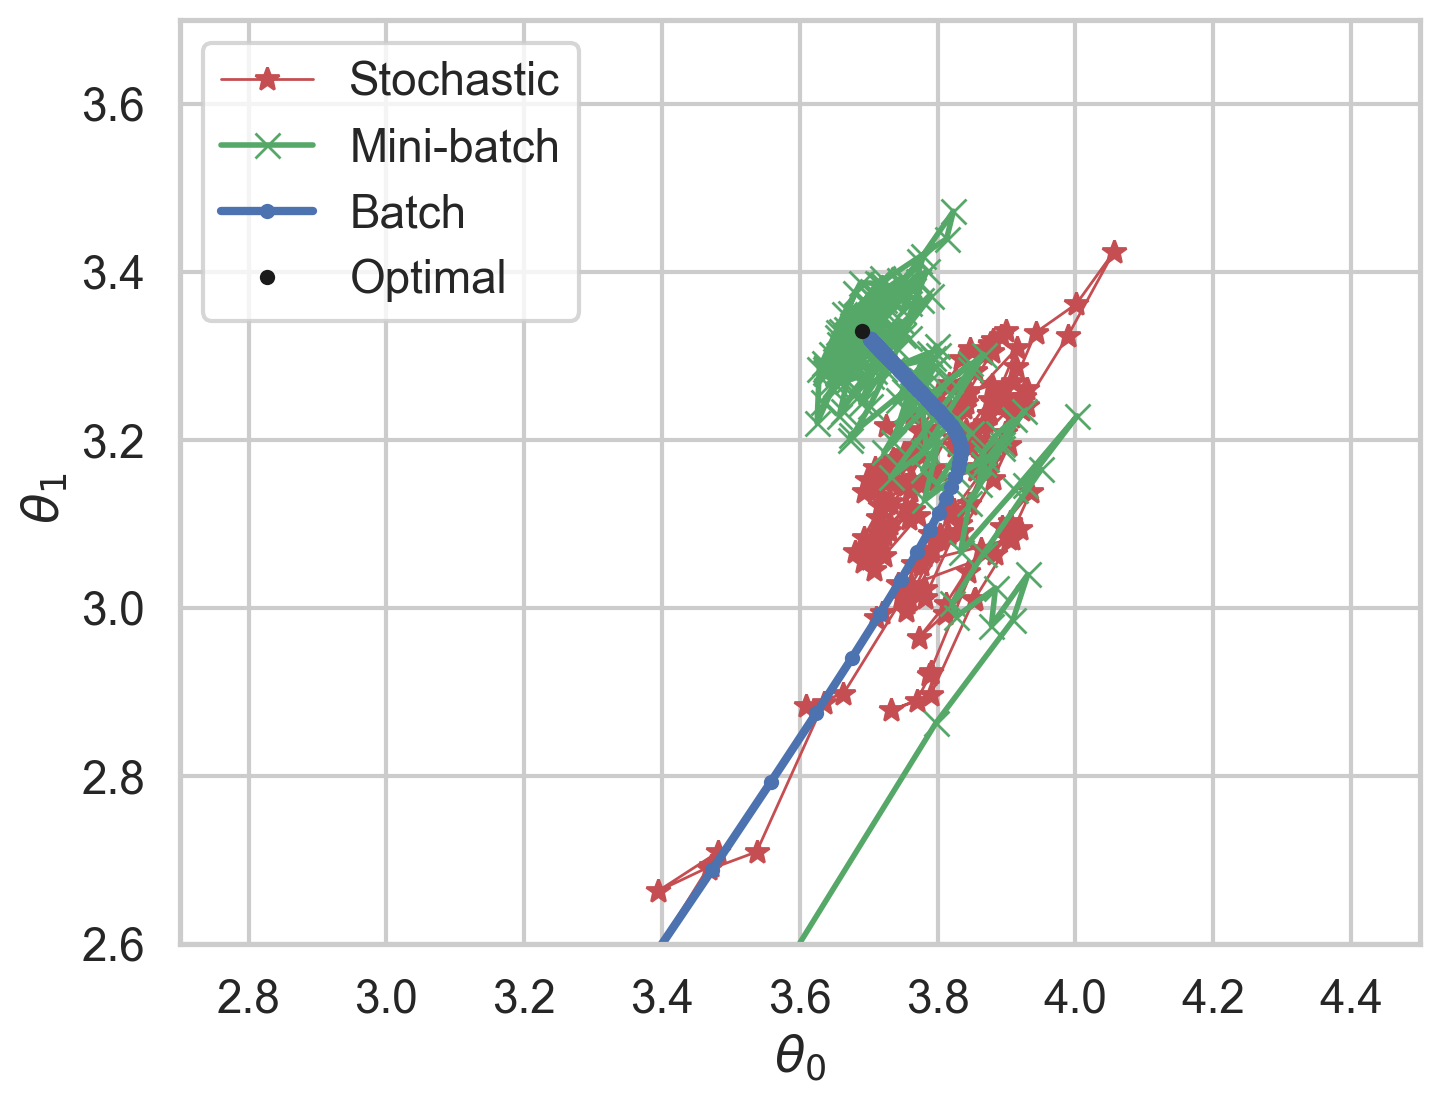

In [149]:
n_show_max = 200

fig, ax = plt.subplots()
ax.plot(
    theta_path_sgd[:n_show_max, 0],
    theta_path_sgd[:n_show_max, 1],
    "*-r",
    linewidth=1,
    label="Stochastic",
)
ax.plot(
    theta_path_mgd[:n_show_max, 0],
    theta_path_mgd[:n_show_max, 1],
    "x-g",
    linewidth=2,
    label="Mini-batch",
)
ax.plot(
    theta_path_bgd[:n_show_max, 0],
    theta_path_bgd[:n_show_max, 1],
    ".-b",
    linewidth=3,
    label="Batch",
)
ax.plot([lin_reg.intercept_[0]], [lin_reg.coef_[0]], ".k", label="Optimal")
ax.legend(loc="upper left")
ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$   ")
ax.axis([2.7, 4.5, 2.6, 3.7])
plt.show()